In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install  -q transformers
!pip install  -q pytorch-lightning
!pip install  -q einops
!pip install  -q tqdm
!pip install  -q 'Pillow==7.1.2'
!pip install  -q datasets
!pip install -q wandb
!pip install -q evaluate seqeval

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 815.2/815.2 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 890.6/890.6 kB 33.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.9/38.9 MB 7.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
fastai 2.7.18 requires pillow>=9.0.0, but you have pillow 7.1.2 which is incompatible.
imageio 2.36.0 requires pillow>=8.3.2, but you have pillow 7.1.2 which is incompatible.
scikit-image 0.24.0 requires pillow>=9.1, but you have pillow 7.1.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!pip install kaggle

In [ ]:
!pip install --upgrade Pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 58.2 MB/s eta 0:00:00
  Attempting uninstall: Pillow
    Found existing installation: Pillow 7.1.2
    Uninstalling Pillow-7.1.2:
      Successfully uninstalled Pillow-7.1.2


#NO NEED TO RUN THIS BLOCK

In [ ]:
## Logging into wandb

import wandb
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("wandb_api")
wandb.login(key=secret_value_0)

In [ ]:
!pip install pytesseract

In [ ]:
## Cloning the repository
!git clone https://github.com/uakarsh/docformer.git

Cloning into 'docformer'...
remote: Enumerating objects: 1418, done.
remote: Counting objects: 100% (352/352), done.
remote: Compressing objects: 100% (162/162), done.
remote: Total 1418 (delta 223), reused 251 (delta 161), pack-reused 1066 (from 1)
Receiving objects: 100% (1418/1418), 4.96 MiB | 6.45 MiB/s, done.
Resolving deltas: 100% (754/754), done.


In [ ]:
## Importing the libraries

import warnings
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)

import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader

import torch.nn.functional as F
import torchvision.models as models
from torchvision.transforms import ToTensor

## Adding the path of docformer to system path
import sys
sys.path.append('./docformer/src/docformer/')

## Importing the functions from the DocFormer Repo
from dataset import resize_align_bbox, get_centroid, get_pad_token_id_start_index, get_relative_distance
from modeling import DocFormerEncoder,ResNetFeatureExtractor,DocFormerEmbeddings,LanguageFeatureExtractor, DocFormer
from transformers import BertTokenizerFast

from datasets import load_dataset
import evaluate

In [ ]:
import pytorch_lightning as pl
pl.seed_everything(42, workers=True)

INFO:lightning_fabric.utilities.seed:Seed set to 42


42

## Preparing the dataset

In [ ]:
## Dataset loading part

dataset = load_dataset("nielsr/funsd-layoutlmv3")
tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

funsd-layoutlmv3.py:   0%|          | 0.00/5.13k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/26.3M [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/9.54M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/149 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50 [00:00<?, ? examples/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [ ]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 11.8 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.


In [ ]:
!pip install datasets --upgrade  # Upgrade datasets to the latest version


In [ ]:
# !pip install datasets --upgrade  # Upgrade datasets to the latest version
from datasets import load_dataset
from datasets.arrow_dataset import Dataset  # Use `Dataset` instead of save_to_disk.

dataset = load_dataset("nielsr/funsd-layoutlmv3")
# dataset.save_to_disk('funsd-layoutlmv3')  # Call `save_to_disk` on a Dataset object.

ValueError: You are trying to load a dataset that was saved using `save_to_disk`. Please use `load_from_disk` instead.

In [ ]:
from datasets import load_dataset, load_from_disk
from datasets.arrow_dataset import Dataset  # Use `Dataset` instead of save_to_disk.

# dataset = load_dataset("nielsr/funsd-layoutlmv3")
# Instead of load_dataset, use load_from_disk to load a saved dataset
dataset = load_from_disk('/content/drive/MyDrive/converted_dataset')
print(dataset)
# dataset.save_to_disk('funsd-layoutlmv3')  # Call `save_to_disk` on a Dataset object.

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'bboxes', 'ner_tags', 'image'],
        num_rows: 16
    })
    test: Dataset({
        features: ['id', 'tokens', 'bboxes', 'ner_tags', 'image'],
        num_rows: 16
    })
})


In [ ]:
def get_tokens_with_boxes(unnormalized_word_boxes, word_ids, tokens,max_seq_len = 512, pad_token_box = [0, 0, 0, 0], pad_token_class = -100):

    # assert len(unnormalized_word_boxes) == len(word_ids), this should not be applied, since word_ids may have higher
    # length and the bbox corresponding to them may not exist

    unnormalized_token_boxes = []
    final_token_label = []

    i = 0
    for word_idx, token in zip(word_ids, tokens):
        if word_idx is None:
            break
        unnormalized_token_boxes.append(unnormalized_word_boxes[word_idx])
        final_token_label.append(token)
        i+=1

    # all remaining are padding tokens so why add them in a loop one by one
    num_pad_tokens = len(word_ids) - i - 1
    if num_pad_tokens > 0:
        unnormalized_token_boxes.extend([pad_token_box] * num_pad_tokens)
        final_token_label.extend([pad_token_class] * num_pad_tokens)


    if len(unnormalized_token_boxes)<max_seq_len:
        unnormalized_token_boxes.extend([pad_token_box] * (max_seq_len-len(unnormalized_token_boxes)))
        final_token_label.extend([pad_token_class] * (max_seq_len-len(final_token_label)))

    return unnormalized_token_boxes, final_token_label

In [ ]:
tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")


def create_features_for_token_cls(image,
        labels,
        tokenizer = tokenizer,
        target_size=(500,384),  # This was the resolution used by the authors
        max_seq_length=512,
        bounding_box = None,
        words = None):


    CLS_TOKEN_BOX = [0, 0, 1000, 1000]    # Can be variable, but as per the paper, they have mentioned that it covers the whole image
    # step 2: resize image
    resized_image = image.resize(target_size)

    # step 4: tokenize words and get their bounding boxes (one word may split into multiple tokens)
    encoding = tokenizer(words,
                         padding="max_length",
                         max_length=max_seq_length,
                         is_split_into_words=True,
                         truncation=True,
                         add_special_tokens=False)

    unnormalized_token_boxes, final_token_label = get_tokens_with_boxes(unnormalized_word_boxes = bounding_box,
                                                     tokens = labels,
                                                     word_ids = encoding.word_ids())

    # step 5: add special tokens and truncate seq. to maximum length
    unnormalized_token_boxes = [CLS_TOKEN_BOX] + unnormalized_token_boxes[:-1]
    final_token_label = [-100] + final_token_label[:-1]
    # add CLS token manually to avoid autom. addition of SEP too (as in the paper)
    encoding["input_ids"] = [tokenizer.cls_token_id] + encoding["input_ids"][:-1]

    # step 6: Add bounding boxes to the encoding dict
    encoding["unnormalized_token_boxes"] = unnormalized_token_boxes

    # step 8: normalize the image
    encoding["resized_scaled_img"] = ToTensor()(resized_image)

    # step 10: rescale and align the bounding boxes to match the resized image size (typically 224x224)
    resized_and_aligned_bboxes = []

    for bbox in unnormalized_token_boxes:
        # performing the normalization of the bounding box
        resized_and_aligned_bboxes.append(resize_align_bbox(tuple(bbox), 1000, 1000, *target_size)) ## The bbox are resized to (1000, 1000)

    encoding["resized_and_aligned_bounding_boxes"] = resized_and_aligned_bboxes
    encoding['token_class'] = final_token_label

    # step 11: add the relative distances in the normalized grid
    bboxes_centroids = get_centroid(resized_and_aligned_bboxes)
    pad_token_start_index = get_pad_token_id_start_index(words, encoding, tokenizer)
    a_rel_x, a_rel_y = get_relative_distance(resized_and_aligned_bboxes, bboxes_centroids, pad_token_start_index)

    # step 12: convert all to tensors
    for k, v in encoding.items():
        encoding[k] = torch.as_tensor(encoding[k])

    encoding.update({
        "x_features": torch.as_tensor(a_rel_x, dtype=torch.int32),
        "y_features": torch.as_tensor(a_rel_y, dtype=torch.int32),
        })


    # step 16: keys to keep, resized_and_aligned_bounding_boxes have been added for the purpose to test if the bounding boxes are drawn correctly or not, it maybe removed
    keys = ['resized_scaled_img', 'x_features','y_features','input_ids','resized_and_aligned_bounding_boxes', 'token_class']

    final_encoding = {k:encoding[k].tolist() for k in keys}

    del encoding
    return final_encoding

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [ ]:
def prepare_examples(sample):
  final_encoding = create_features_for_token_cls(image = sample['image'],
                                              bounding_box = sample['bboxes'],
                                              words = sample['tokens'],
                                              labels = sample['ner_tags'])

  return final_encoding

In [ ]:
column_names = list(dataset['train'].features.keys())

In [ ]:
column_names

['id', 'tokens', 'bboxes', 'ner_tags', 'image']

In [ ]:
from datasets import Features, Sequence, ClassLabel, Value, Array2D, Array3D

# we need to define custom features for `set_format` (used later on) to work properly
features = Features({
    'resized_scaled_img': Array3D(dtype="float32", shape=(3, 384, 500)),
    'x_features': Array2D(dtype="int64", shape=(512, 8)),
    'y_features': Array2D(dtype="int64", shape=(512, 8)),
    'input_ids': Sequence(feature=Value(dtype='int64')),
    'resized_and_aligned_bounding_boxes': Array2D(dtype="int64", shape=(512, 4)),
    'token_class' : Sequence(feature=Value(dtype='int64'))
})

train_dataset = dataset["train"].map(
    prepare_examples,
    remove_columns=column_names,
    batched=False,
    features=features
)

eval_dataset = dataset["test"].map(
    prepare_examples,
    remove_columns=column_names,
    batched=False,
    features=features
)

Map:   0%|          | 0/16 [00:00<?, ? examples/s]

In [ ]:
columns = list(train_dataset[0].keys())

In [ ]:
train_dataset.set_format(type='torch', columns= columns)
eval_dataset.set_format(type='torch', columns=columns)

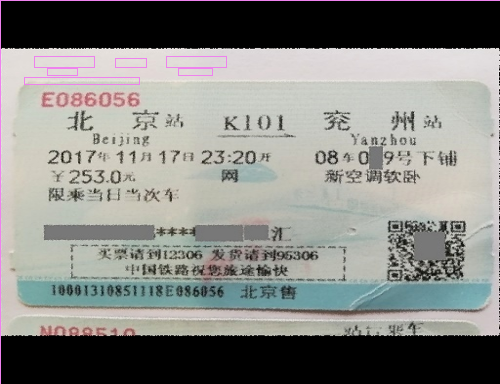

In [ ]:
sample = train_dataset[0]

image = sample['resized_scaled_img']
x_features = sample['x_features']
y_features = sample['y_features']
input_ids = sample['input_ids']
resized_and_aligned_bounding_boxes = sample['resized_and_aligned_bounding_boxes']
token_class = sample['token_class']

from torchvision import transforms
from PIL import Image, ImageDraw


image = transforms.ToPILImage()(torch.tensor(image))
# create rectangle image
draw_on_img = ImageDraw.Draw(image)

for box in resized_and_aligned_bounding_boxes.tolist():
  draw_on_img.rectangle(box, outline ="violet")

image

In [ ]:
def collate_fn(data_bunch):

  '''
  A function for the dataloader to return a batch dict of given keys

  data_bunch: List of dictionary
  '''

  dict_data_bunch = {}

  for i in data_bunch:
    for (key, value) in i.items():
      if key not in dict_data_bunch:
        dict_data_bunch[key] = []
      dict_data_bunch[key].append(value)

  for key in list(dict_data_bunch.keys()):
      dict_data_bunch[key] = torch.stack(dict_data_bunch[key], axis = 0)

  return dict_data_bunch

In [ ]:
class DataModule(pl.LightningDataModule):

  def __init__(self, batch_size:int = 2):
    super(DataModule, self).__init__()
    self.batch_size = batch_size

  def train_dataloader(self):
    return DataLoader(train_dataset, batch_size = self.batch_size,
                      shuffle = True)

  def val_dataloader(self):
    return DataLoader(eval_dataset, batch_size = self.batch_size,
                      shuffle = False)

In [ ]:
from datasets.features import ClassLabel

features = dataset["train"].features
column_names = dataset["train"].column_names
image_column_name = "image"
text_column_name = "tokens"
boxes_column_name = "bboxes"
label_column_name = "ner_tags"

# In the event the labels are not a `Sequence[ClassLabel]`, we will need to go through the dataset to get the
# unique labels.
def get_label_list(labels):
    unique_labels = set()
    for label in labels:
        unique_labels = unique_labels | set(label)
    label_list = list(unique_labels)
    label_list.sort()
    return label_list

if isinstance(features[label_column_name].feature, ClassLabel):
    label_list = features[label_column_name].feature.names
    # No need to convert the labels since they are already ints.
    id2label = {k: v for k,v in enumerate(label_list)}
    label2id = {v: k for k,v in enumerate(label_list)}
else:
    label_list = get_label_list(dataset["train"][label_column_name])
    id2label = {k: v for k,v in enumerate(label_list)}
    label2id = {v: k for k,v in enumerate(label_list)}
print(f"A total of {len(id2label)} labels were found: {id2label}")
print(f"A total of {len(label2id)} labels were found: {label2id}")
num_labels = len(label_list)

A total of 9 labels were found: {0: 'other', 1: 'ticket_num', 2: 'starting_station', 3: 'train_num', 4: 'destination_station', 5: 'date', 6: 'ticket_rates', 7: 'seat_category', 8: 'name'}
A total of 9 labels were found: {'other': 0, 'ticket_num': 1, 'starting_station': 2, 'train_num': 3, 'destination_station': 4, 'date': 5, 'ticket_rates': 6, 'seat_category': 7, 'name': 8}


In [ ]:
def get_labels(predictions, references):

    # Transform predictions and references tensors to numpy arrays
    if predictions.device.type == "cpu":
        y_pred = predictions.detach().clone().numpy()
        y_true = references.detach().clone().numpy()

    else:
        y_pred = predictions.detach().cpu().clone().numpy()
        y_true = references.detach().cpu().clone().numpy()

    # Remove ignored index (special tokens)
    true_predictions = [
        [labels[p] for (p, l) in zip(pred, gold_label) if l != -100]
        for pred, gold_label in zip(y_pred, y_true)
    ]
    true_labels = [
        [labels[l] for (p, l) in zip(pred, gold_label) if l != -100]
        for pred, gold_label in zip(y_pred, y_true)
    ]
    return true_predictions, true_labels

In [ ]:
labels = dataset["train"].features['ner_tags'].feature.names

## Modeling:

In [ ]:
config = config = {
        "coordinate_size": 96,
        "hidden_dropout_prob": 0.1,
        "hidden_size": 768,
        "image_feature_pool_shape": [7, 7, 256],
        "intermediate_ff_size_factor": 4,
        "max_2d_position_embeddings": 1000,
        "max_position_embeddings": 512,
        "max_relative_positions": 8,
        "num_attention_heads": 12,
        "num_hidden_layers": 12,
        "pad_token_id": 0,
        "shape_size": 96,
        "vocab_size": 30522,
        "layer_norm_eps": 1e-12,
    "classes": 9 #7
    }

class DocFormerForMLM(DocFormer):

    def __init__(self, config):
        super().__init__(config)
        self.mlm_token = nn.Linear(config['hidden_size'], config['vocab_size'])

    def forward(self, batch):
        output = super().forward(batch)
        mlm_token = self.mlm_token(output)
        return {"mlm_token" : mlm_token}


class PLModel(pl.LightningModule):

    def __init__(self, config):
        super().__init__()
        self.save_hyperparameters()
        self.config = config
        self.vocab_size = config['vocab_size']
        self.model = DocFormerForMLM(config)

    def forward(self, batch):
        return self.model(batch)

    def training_step(self, batch, batch_idx):
        output = self(batch)
        loss = self.loss_fn(batch["labels"], output["mlm_token"])['mlm_loss']

        self.log('train_loss', loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        output = self(batch)

        loss = self.loss_fn(batch["labels"], output["mlm_token"])['mlm_loss']

        self.log('val_loss', loss, prog_bar=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.AdamW(self.model.parameters(), lr=self.args.lr)


ckpt_path = "/content/drive/MyDrive/docformer_best_ckpt.ckpt"
model = PLModel.load_from_checkpoint(ckpt_path, map_location = "cpu", config = config)

INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.9.0 to v2.4.0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint drive/MyDrive/docformer_best_ckpt.ckpt`
Some weights of LayoutLMForTokenClassification were not initialized from the model checkpoint at microsoft/layoutlm-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
!pip install wandb

In [ ]:
import wandb #Import wandb library

class PL_Model(pl.LightningModule):

  def __init__(self, config, model_name = 'docformer-base', lr = 5e-5):

    super(PL_Model, self).__init__()
    self.save_hyperparameters()
    self.resnet = ResNetFeatureExtractor()
    self.resnet.load_state_dict(model.model.extract_feature.visual_feature.state_dict())

    self.embeddings = DocFormerEmbeddings(config)
    self.embeddings.load_state_dict(model.model.extract_feature.spatial_feature.state_dict())

    self.lang_emb = LanguageFeatureExtractor()
    self.lang_emb.load_state_dict(model.model.extract_feature.language_feature.state_dict())

    self.config = config
    self.dropout = nn.Dropout(config['hidden_dropout_prob'])
    self.linear_layer = nn.Linear(in_features = config['hidden_size'], out_features = config['classes'])
    self.encoder = DocFormerEncoder(config)

    ## Metrics
    self.train_metric = evaluate.load("seqeval")
    self.val_metric = evaluate.load("seqeval")

    ## Parameters
    self.lr = lr

  def forward(self, batch_dict):
    x_feat = batch_dict['x_features']
    y_feat = batch_dict['y_features']

    token = batch_dict['input_ids']
    img = batch_dict['resized_scaled_img']

    v_bar_s, t_bar_s = self.embeddings(x_feat,y_feat)
    v_bar = self.resnet(img)
    t_bar = self.lang_emb(token)
    out = self.encoder(t_bar,v_bar,t_bar_s,v_bar_s)
    out = self.linear_layer(out)
    return out

  def configure_optimizers(self):
    return torch.optim.AdamW(self.parameters(), lr = self.hparams['lr'])

  def training_step(self, batch, batch_idx):

    ## Forward Propagatipn
    outputs = self.forward(batch)
    loss = F.cross_entropy(outputs.transpose(1, 2), batch["token_class"], ignore_index = -100)
    ## Predictions and adding the metrics
    predictions = outputs.argmax(-1)
    true_predictions, true_labels = get_labels(predictions, batch["token_class"])
    self.train_metric.add_batch(references=true_labels, predictions=true_predictions)

    ## Logging Purpose
    results = self.train_metric.compute()
    self.log("train_loss", loss.item(), prog_bar = True)
    self.log("train_overall_fl", results["overall_f1"], prog_bar = True)
    self.log("train_overall_recall", results["overall_recall"], prog_bar = True)
    self.log("train_overall_precision", results["overall_precision"], prog_bar = True)

    ## Backpropagation
    return loss

  def validation_step(self, batch, batch_idx):

    outputs = self.forward(batch)
    loss = F.cross_entropy(outputs.transpose(1, 2), batch["token_class"], ignore_index = -100)

    predictions = outputs.argmax(-1)
    true_predictions, true_labels = get_labels(predictions, batch["token_class"])
    self.val_metric.add_batch(references=true_labels, predictions=true_predictions)

    ## Logging Purpose
    results = self.val_metric.compute()
    self.log("val_loss", loss.item(), prog_bar = True)
    self.log("val_overall_fl", results["overall_f1"], prog_bar = True)
    self.log("val_overall_recall", results["overall_recall"], prog_bar = True)
    self.log("val_overall_precision", results["overall_precision"], prog_bar = True)

    return loss

In [ ]:
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.loggers import WandbLogger

def main():

    checkpoint_callback = ModelCheckpoint(
        dirpath="./docformer/models", monitor="val_loss", mode="min", filename = 'docformer_best_ckpt'
    )

    wandb.init(config = config, project="DocFormer on FUNSD")
    wandb_logger = WandbLogger(project="DocFormer on FUNSD", entity="iakarshu")

    max_epochs = 50
    trainer = pl.Trainer(
        max_epochs = max_epochs,
        default_root_dir="./docformer/logs",
        accelerator="auto",
        devices="auto",
        logger=wandb_logger,
        callbacks=[checkpoint_callback]
    )

    pl_model = PL_Model(config)
    pl_dl = DataModule()

    trainer.fit(pl_model, pl_dl)

    return pl_model, pl_dl

In [ ]:
#607d825699b001d2427f779ec2b7d7735dd0da4f

In [ ]:
if __name__ == "__main__":
  pl_model, pl_dl = main()

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
Some weights of LayoutLMForTokenClassification were not initialized from the model checkpoint at microsoft/layoutlm-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
import os
model_path = os.path.join('./docformer/models', os.listdir('./docformer/models')[0])
# Call load_from_checkpoint on the class, not the instance
pl_model = PL_Model.load_from_checkpoint(model_path, config=config) # Pass config to the constructor

Some weights of LayoutLMForTokenClassification were not initialized from the model checkpoint at microsoft/layoutlm-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
import os
model_path = os.path.join('./docformer/models', os.listdir('./docformer/models')[0])
pl_model = PL_Model(config)
pl_model = pl_model.load_from_checkpoint(model_path)

Some weights of LayoutLMForTokenClassification were not initialized from the model checkpoint at microsoft/layoutlm-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


TypeError: The classmethod `PL_Model.load_from_checkpoint` cannot be called on an instance. Please call it on the class type and make sure the return value is used.

In [ ]:
from tqdm.auto import tqdm

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
eval_metric = evaluate.load("seqeval")
pl_model.eval();

model = pl_model.to(device)
pl_dl = DataModule()
for idx, batch in enumerate(tqdm(pl_dl.val_dataloader())):
    # move batch to device
    batch = {k:v.to(device) for k,v in batch.items()}
    with torch.no_grad():
      outputs = model.forward(batch)

    predictions = outputs.argmax(-1)
    true_predictions, true_labels = get_labels(predictions, batch["token_class"])
    eval_metric.add_batch(references=true_labels, predictions=true_predictions)

  0%|          | 0/25 [00:00<?, ?it/s]

In [ ]:
results = eval_metric.compute()

In [ ]:
for key in ['overall_precision', 'overall_recall', 'overall_f1', 'overall_accuracy']:
  print_statement = '{0: <30}'.format(str(key) + " has value:")
  print(print_statement, results[key])

overall_precision has value:   0.09330143540669857
overall_recall has value:      0.13663663663663664
overall_f1 has value:          0.11088545897644192
overall_accuracy has value:    0.27759274147237856
